In [ ]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import datetime
import hmmlearn.hmm as hmm
import re
from datetime import date
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
def cpi_convert():
    df = pd.read_excel('historical-cpi-u-202602.xlsx', header=None)
    data = df.iloc[5:119].copy()
    data.columns = ['indent', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    data = data[['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']].copy()
    data['Year'] = data['Year'].astype(int)

    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    melted = data.melt(id_vars='Year', value_vars=months, var_name='Month', value_name='CPI')
    melted = melted.sort_values(['Year']).reset_index(drop=True)
    melted['CPI'] = pd.to_numeric(melted['CPI'].replace({'–': None, '-': None}), errors='coerce')
    melted = melted.dropna(subset=['CPI'])
    melted['Date'] = melted['Month'] + '-' + melted['Year'].astype(str)
    melted = melted[['Date', 'CPI']].reset_index(drop=True)
    # melted.columns = ['Date', 'CPI']

    melted.to_excel('trial.xlsx', index=False)
cpi_convert()


In [ ]:
def cpi_convert():
    df = pd.read_excel('historical-cpi-u-202602.xlsx', header=None)
    data = df.iloc[5:119].copy()
    num_months = [str(i) for i in range(1, 13)]
    data.columns = ['indent', 'Year'] + num_months
    data = data.drop(columns= ['indent'])
    
    # Combining the dataframe into a single column
    data = data.melt(id_vars='Year', value_vars=num_months, var_name='Month', value_name='CPI')
    data['Date'] = pd.to_datetime(data['Year'].astype(str) + data['Month'], format='%Y%m').dt.strftime('%Y-%m')

    data = data.sort_values(['Date']).reset_index(drop=True)
    data = data[['Date', 'CPI']]
    data = data[data['CPI'] != '–']

    data.to_excel('historical-cpi-u-reorganized.xlsx', index=False)

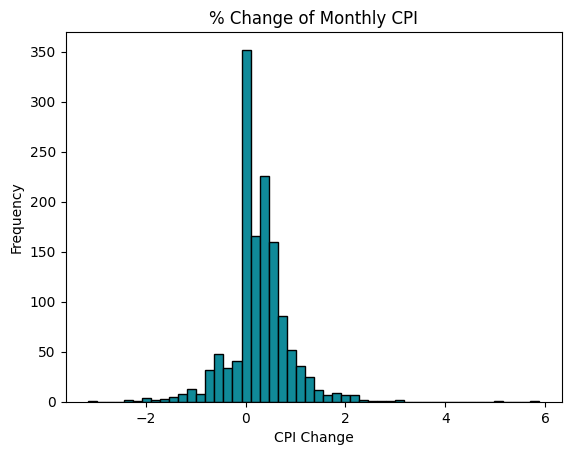

In [2]:
df = pd.read_excel('historical-cpi-u-reorganized.xlsx')
df['Change%'] = df['CPI'].pct_change()*100
df = df.dropna()

plt.hist(df['Change%'], bins=50, color='#108A99', edgecolor='black')
plt.title("% Change of Monthly CPI")
plt.xlabel("CPI Change")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df.nlargest(n=20, columns=['Change%'])
df.nsmallest(n=20, columns=['Change%'])

,Month-Year,CPI,Change%
48,Oct-1917,13.500,26.168224
84,Apr-1920,20.300,25.308642
408,Aug-1947,22.500,24.309392
72,Jul-1919,17.400,22.535211
60,May-1918,14.500,20.833333
396,Nov-1946,21.300,19.662921
405,Dec-1946,21.500,17.486339
804,Apr-1980,81.000,17.221418
348,Sep-1942,16.500,15.384615
80,Dec-1919,18.900,15.243902


Mean Predicted Cost: 2.99
95th Percentile (Worst Case): 5.26


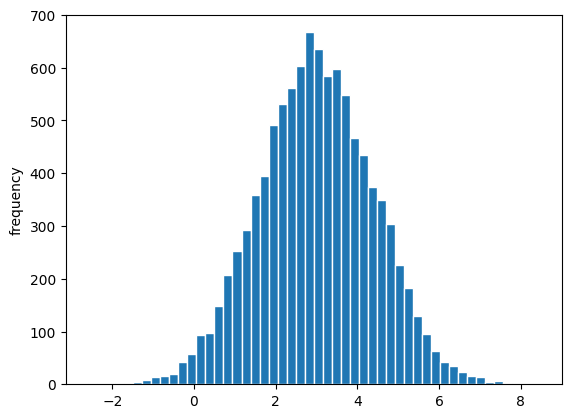

In [3]:
# python anywhere or streamlit
# investing.com for histroical data, udpate with yahoo

data = [1,2,3,4,5]
num_simulations = 10000
mean = np.mean(data)
std_dev = np.std(data)
pct_to_target = np.random.normal(mean, std_dev, num_simulations).round(2)
print(f"Mean Predicted Cost: {pct_to_target.mean():.2f}")
print(f"95th Percentile (Worst Case): {np.percentile(pct_to_target, 95):.2f}")
plt.hist(pct_to_target, bins=50, edgecolor='white')
plt.ylabel('frequency')
plt.show()


# display S&P returns
# Simulate MC simulation based on historical data
# display distributions of returns after 1 year with VaR and ES
# Compare to the CPI 

# hmmlearn for HMM

In [4]:
print(df)

         Date      CPI   Change%
1     1913-02    9.800  0.000000
2     1913-03    9.800  0.000000
3     1913-04    9.800  0.000000
4     1913-05    9.700 -1.020408
5     1913-06    9.800  1.030928
...       ...      ...       ...
1352  2025-09  324.800  0.254340
1353  2025-11  324.122 -0.208744
1354  2025-12  324.054 -0.020980
1355  2026-01  325.252  0.369691
1356  2026-02  326.785  0.471327

[1356 rows x 3 columns]


In [5]:
import numpy as np

# Year-over-year inflation
df["inflation_yoy"] = df["CPI"].pct_change(12)

# Month-over-month inflation
df["inflation_mom"] = df["CPI"].pct_change(1)

# Rolling volatility (proxy for instability)
df["volatility"] = df["inflation_mom"].rolling(6).std()

df = df.dropna()

In [6]:
features = ["inflation_yoy", "inflation_mom", "volatility"]
X = df[features].values

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
from hmmlearn.hmm import GaussianHMM

n_states = 3  # try 2–4

model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X_scaled)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [9]:
hidden_states = model.predict(X_scaled)

df["regime"] = hidden_states

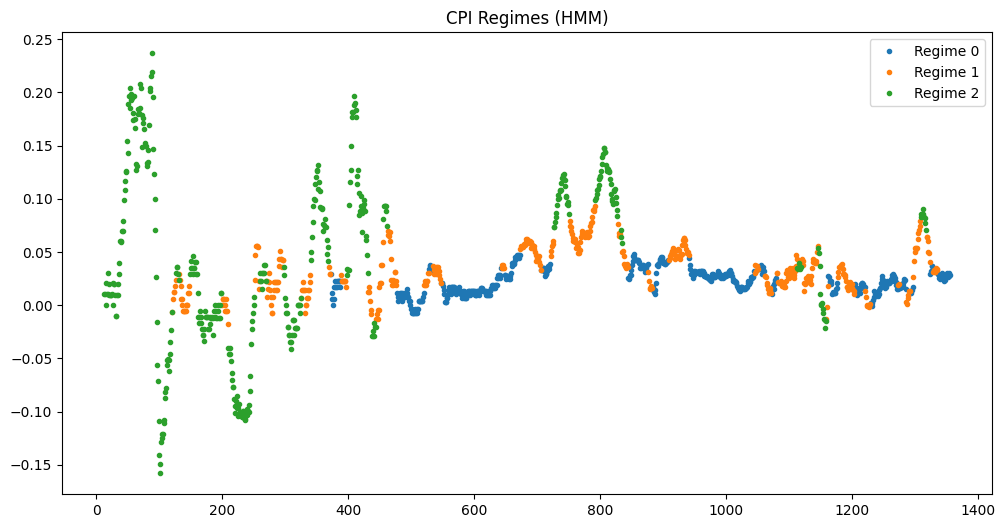

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(n_states):
    plt.plot(
        df.index[df["regime"] == i],
        df["inflation_yoy"][df["regime"] == i],
        ".",
        label=f"Regime {i}"
    )

plt.legend()
plt.title("CPI Regimes (HMM)")
plt.show()

In [11]:
for i in range(n_states):
    print(f"\nRegime {i}")
    print(df[df["regime"] == i][features].mean())


Regime 0
inflation_yoy    0.022020
inflation_mom    0.001901
volatility       0.001876
dtype: float64

Regime 1
inflation_yoy    0.033560
inflation_mom    0.002778
volatility       0.003298
dtype: float64

Regime 2
inflation_yoy    0.044844
inflation_mom    0.003313
volatility       0.007014
dtype: float64


In [12]:
print(model.transmat_)

[[9.60838587e-01 3.91614125e-02 1.90575883e-20]
 [4.75063780e-02 9.15059133e-01 3.74344887e-02]
 [2.95367831e-09 4.08027295e-02 9.59197268e-01]]


In [ ]:
import numpy as np

def compute_bic(model, X):
    log_likelihood = model.score(X)
    n_params = model.n_components**2 + 2 * model.n_components * X.shape[1]
    return -2 * log_likelihood + n_params * np.log(len(X))

for k in range(2, 6):
    model = GaussianHMM(n_components=k, covariance_type="full", n_iter=500)
    model.fit(X_scaled)
    print(f"States: {k}, BIC: {compute_bic(model, X_scaled)}")

In [ ]:
unemployment = pd.read_csv('UNRATE.csv')
cpi =- pd.read_csv('CPIAUCSL.csv')
merged = unemployment.merge(cpi, on='observation_date')
merged = merged.rename(columns = {"observation_date": "Date", "UNRATE": "unemployment_rate", "CPIAUCSL": "cpi"})
merged["Date"] = pd.to_datetime(merged["Date"]).dt.strftime('%Y-%m')


In [ ]:
df = pd.read_excel('BCDC_spreadsheet_for_website.xlsx')
peak = df.iloc[3:37, 2]
peak.apply(lambda x: x[:x.find("(")].strip())

In [ ]:
new_data = []
flag = []
df = pd.read_excel('BCDC_spreadsheet_for_website.xlsx')
peak = df.iloc[3:37, 2]
trough = df.iloc[3:37, 3]

for i in range(len(peak)):
    start = (peak.iloc[i])[:(peak.iloc[i]).find("(")].strip()
    end = (trough.iloc[i])[:(trough.iloc[i]).find("(")].strip()

    month_range = pd.period_range(start=start, end=end, freq="M").strftime('%Y-%m').to_list()

    new_data = new_data + month_range
    flag.extend([1] * len(month_range))

    if i == len(peak)-1:
        month_range = pd.period_range(start=end, end=date.today().strftime('%Y-%m') , freq="M").strftime('%Y-%m').to_list()
        new_data = new_data + month_range
        flag.extend([0] * len(month_range))
    else: 
        next_start = (peak.iloc[i+1])[:(peak.iloc[i+1]).find("(")].strip()
        month_range = pd.period_range(start=end, end=next_start , freq="M").strftime('%Y-%m').to_list()
        new_data = new_data + month_range
        flag.extend([0] * len(month_range))

new_df = pd.DataFrame({"Month": new_data, "Flag": flag})
new_df.to_csv('temp.csv', index=False)


In [ ]:
temp = pd.read_csv('temp.csv')
temp = temp.rename(columns={"Month": "Date"})

In [ ]:
data = pd.merge(merged, temp, on='Date', how='left')

In [ ]:
data["CPI_1M_change"] = data['cpi'].pct_change()
data["unemployment_rate_1m_change"] = data['unemployment_rate'].pct_change()

In [ ]:
plt.plot(data["Date"], data["cpi"], label = "CPI 1M Change")
plt.plot(data["Date"], data["unemployment_rate"], label = "Unemployment 1M Change")
plt.xlabel("Date")
plt.xticks(data["Date"][::36], rotation=90)
plt.show()

NameError: name 'plt' is not defined

In [ ]:
data['Date'][data['Flag'] == 1]


In [ ]:
fig = px.line(data, x="Date", y= ['cpi', 'unemployment_rate'])

for i in range(len(data)):
    if data["Flag"].iloc[i] == 1:
        fig.add_vrect(x0=data["Date"].iloc[i]i, x1=data["Date"].iloc[i+1],
        fillcolor='red', opacity=0.2, line_width=0)
    fig.show()

In [ ]:
unemployment = pd.read_csv('UNRATE.csv')
null_values = unemployment.loc[unemployment['UNRATE'].isnull() == True].index[0]

unemployment.iloc[null_values,1] = (unemployment.iloc[null_values - 1, 1] + unemployment.iloc[null_values + 1, 1]) /2 


unemployment.iloc[null_values]

In [ ]:
fig = make_subplot(specs=[{'secondary_y':True}])

fig.add_trace(
    go.Scatter(x=data["Date"], y=data['cpi'], name='CPI data'),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=data["Date"], y=data['unemployment_rate'], name='unemployment rate data'),
    secondary_y=False
)

fig.update_layout(
    titel_text="Unemployment, CPI and Recession"
)

for i in range(len(data)):
    if data["Flag"].iloc[i] == 1:
        fig.add_vrect(x0=data["Date"].iloc[i]i, x1=data["Date"].iloc[i+1],
        fillcolor='red', opacity=0.2, line_width=0)

fig.update_xaxes(title_text='xaxis title')

fig.update_yaxes(title_text="CPI", secondary_y=False)
fig.update_yaxes(title_text="Unemployment Rate", secondary_y=False)
fig.show()